In [1]:
from astropy import constants as const
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

def grid_R(NR, dR):
    R = np.zeros(NR)
    l = 10 / dR
    for i in range(NR):
        if i * dR < 10:
            R[i] = i * dR
        else:
            R[i] = 10** ((i + l ) / 2 / l)
    return R
def grid_Z(NZ, dZ):
    Z = np.zeros(NZ)
    l = 1 / dZ
    for i in range(NZ):
        if i * dZ < 1:
            Z[i] = i * dZ
        else:
            Z[i] = 10** ((i - l) / 2 / l)
    return Z
NR = 300
NZ = 250
Rf = grid_R(NR + 1,0.1)
Zf = grid_Z(NZ + 1,0.02)
Rc = (Rf[1:] + Rf[:-1]) / 2
Zc = (Zf[1:] + Zf[:-1]) / 2

In [14]:
Zc[198]

np.float64(30.55123576457803)

In [2]:

ndis_C = np.fromfile("ndis_C_log_gauss_inj_dt10000_vZ_dZ2_PLM.bin",dtype = np.float64).reshape(100,NR + 4, NZ + 4)
ndis_C_in = ndis_C[:,2:-2,2:-2]
ndis_C_log = np.log10(ndis_C_in + 1e-100)

fig, ax = plt.subplots()

ndis = ax.pcolormesh(Rc, Zc, ndis_C_in[0].T,shading="auto", vmin = 0, vmax = 100 )

cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('linear scale') 

def animate(i):
    ndis.set_array(ndis_C_in[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=100,
    interval=10,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())

In [28]:
ani.save("ndis_C_log_gauss_inj_dt1000_vZ_dZ2_PLM.mp4", writer="ffmpeg", fps=30, dpi=200)

Text(0.5, 1.0, 'Total number of particles VS time')

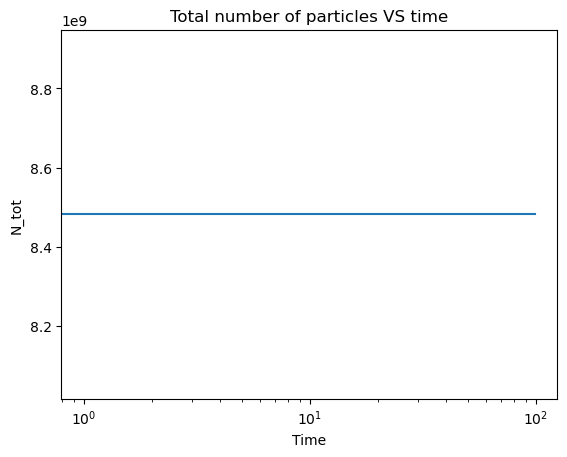

In [23]:
dV = Rc[:, None] * np.diff(Rf)[:,None] * np.diff(Zf)[None,:]
N_tot = np.sum(ndis_C_in * dV[None,:], axis = (1,2))
t = np.arange(100)
plt.plot(t, N_tot)
plt.xscale("log")
plt.ylabel("N_tot")
plt.xlabel("Time")
plt.title("Total number of particles VS time")

Text(0.5, 1.0, 'Distribution extension VS time')

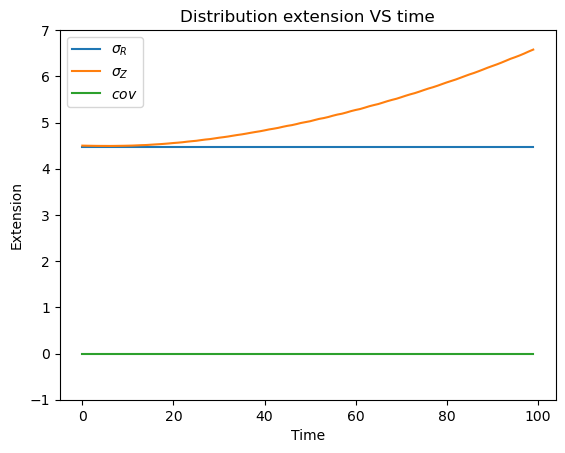

In [29]:
dV = Rc[:, None] * np.diff(Rf)[:,None] * np.diff(Zf)[None,:]
N_tot = np.sum(ndis_C_in * dV[None,:], axis = (1,2))
t = np.arange(100)

mc_R = np.sum(ndis_C_in * Rc[None, :, None] * dV[None,:], axis = (1,2)) / N_tot
mc_Z = np.sum(ndis_C_in * Zc[None, None, :] * dV[None,:], axis = (1,2)) / N_tot

sigma_R = np.sum((Rc[None,:,None] - mc_R[:,None,None])**2 * ndis_C_in * dV[None,:], axis = (1,2)) / N_tot 
sigma_Z = np.sum((Zc[None,None,:] - mc_Z[:,None,None])**2 * ndis_C_in * dV[None,:], axis = (1,2)) / N_tot 
cov = np.sum((Rc[None,:,None]-mc_R[:,None,None])*(Zc[None,None,:]-mc_Z[:,None,None])*ndis_C_in*dV[None,:,:],axis=(1,2))/N_tot
plt.plot(t, sigma_R, label = f"$\sigma_R$")
plt.plot(t, sigma_Z, label = f"$\sigma_Z$")
plt.plot(t, cov, label = f"$cov$")
plt.legend()
plt.ylim(-1,7)
plt.ylabel("Extension")
plt.xlabel("Time")
plt.title("Distribution extension VS time")

Text(0.5, 1.0, 'Numerical diffusion VS time')

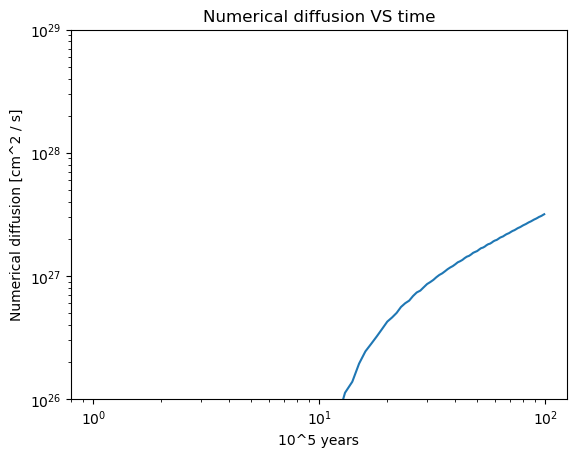

In [26]:
D_num = (sigma_Z[1:] - sigma_Z[0]) / 2 / t[1:] /1e6
D_num = D_num * u.kpc**2 / u.yr
D_num = D_num.to(u.cm**2 / u.s).value
plt.plot(t[1:], D_num)
plt.xscale("log")
plt.yscale("log")
plt.ylim(1e26,1e29)
plt.xlabel("10^5 years")
plt.ylabel("Numerical diffusion [cm^2 / s]")

plt.title("Numerical diffusion VS time")

Text(0.5, 1.0, 'radial profile in z direction VS time')

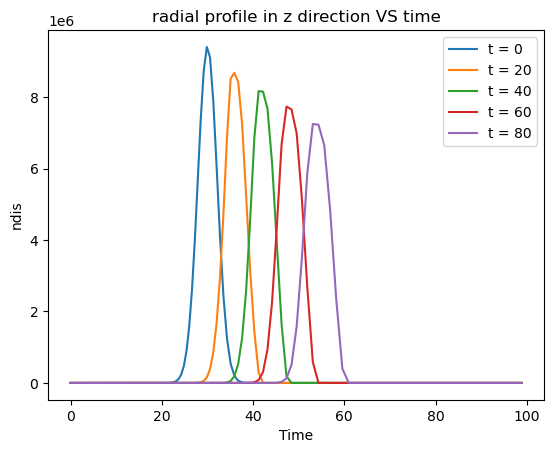

In [27]:
for i in range(5):
    plt.plot(Zc, ndis_C_in[i*20, 197], label = f"t = {i*20}")
plt.legend()
plt.ylabel("ndis")
plt.xlabel("Time")
plt.title("radial profile in z direction VS time")

In [30]:
381.8 + 19.94

401.74